# 05.2 Model Comparison: Baseline vs PriceSequenceGRU

Comparación reproducible entre `MarketValueNet` y `PriceSequenceGRU`.

**Objetivo**
- contrastar las métricas held-out guardadas en disco para ambos modelos
- comparar ambos sobre un universo común de diagnóstico
- revisar cobertura, desacuerdos y overlap de oportunidades en mercados activos
- decidir si el modelo secuencial aporta señal nueva o solo replica al baseline

**Prerequisitos**
- `data/models/market_value_baseline/best_market_model.pt`
- `data/models/price_sequence_gru/best_ts_gru_model.pt`
- `data/processed/` y `data/processed_ts/`


## 1. Setup

Cargamos raw data, checkpoints y pipeline del baseline. Si alguno de estos artefactos falta, la comparación todavía no está lista.

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from IPython.display import display
from sklearn.metrics import average_precision_score, roc_auc_score, precision_score, recall_score, f1_score, PrecisionRecallDisplay

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.config import load_config
from src.features.pipeline import FeaturePipeline
from src.model.architecture import MarketValueNet
from src.model.ts_architecture import PriceSequenceGRU
from src.model.ts_dataset import TimeSeriesMarketDataset
from src.scoring.scorer import score_active_markets
from src.scoring.ts_scorer import score_active_markets_ts, score_resolved_markets_ts
from src.scoring.signals import generate_signals
from src.data.preprocessing import build_snapshot_market, infer_resolution_from_market

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

cfg = load_config(str(ROOT / 'config' / 'config.yaml'))
RAW = ROOT / 'data' / 'raw'
PROCESSED = ROOT / cfg['data']['processed_dir']
PROCESSED_TS = ROOT / cfg['ts_data']['processed_dir']
FIGURES = ROOT / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

BASELINE_DIR = ROOT / cfg['training']['save_dir']
TS_DIR = ROOT / cfg['ts_training']['save_dir']
baseline_model_path = BASELINE_DIR / 'best_market_model.pt'
ts_model_path = TS_DIR / 'best_ts_gru_model.pt'
pipeline_dir = PROCESSED / 'pipeline'

assert baseline_model_path.exists(), f'Falta modelo baseline: {baseline_model_path}'
assert ts_model_path.exists(), f'Falta modelo TS: {ts_model_path}'
assert pipeline_dir.exists(), f'Falta pipeline baseline: {pipeline_dir}'
assert PROCESSED_TS.exists(), f'Falta dataset TS: {PROCESSED_TS}'


## 2. Definición del universo común de evaluación

Primero leemos las métricas held-out guardadas por cada entrenamiento.
Después construimos un **universo común de diagnóstico** usando mercados que el TS sí puede secuenciar; eso no sustituye el test puro, pero sí permite comparar scores lado a lado.


In [2]:
with open(RAW / 'resolved_markets.json') as f:
    resolved_markets = json.load(f)
with open(RAW / 'active_markets.json') as f:
    active_markets = json.load(f)
with open(RAW / 'price_histories.json') as f:
    price_histories = json.load(f)
with open(RAW / 'order_books.json') as f:
    order_books = json.load(f)

baseline_run = json.loads((BASELINE_DIR / 'run_config.json').read_text())
baseline_test = json.loads((BASELINE_DIR / 'test_metrics.json').read_text())
ts_run = json.loads((TS_DIR / 'run_config.json').read_text())
ts_test = json.loads((TS_DIR / 'test_metrics.json').read_text())

def extract_summary(name, run_cfg, test_cfg):
    split = run_cfg.get('split', {})
    default = test_cfg.get('default_threshold', {})
    return {
        'model': name,
        'split_strategy': split.get('strategy'),
        'train_size': split.get('train_size'),
        'val_size': split.get('val_size'),
        'test_size': split.get('test_size'),
        'test_positive_rate': split.get('class_balance', {}).get('test_positive_rate'),
        'accuracy': default.get('accuracy'),
        'precision': default.get('precision'),
        'recall': default.get('recall'),
        'f1': default.get('f1'),
        'roc_auc': default.get('roc_auc', default.get('auc_roc')),
        'pr_auc': default.get('pr_auc'),
    }

heldout_df = pd.DataFrame([
    extract_summary('MarketValueNet', baseline_run, baseline_test),
    extract_summary('PriceSequenceGRU', ts_run, ts_test),
])
print('Comparación de métricas held-out guardadas en disco:')
display(heldout_df.round(4))
print('\nNota: estas métricas no son perfectamente apples-to-apples porque hoy baseline y TS usan splits distintos.')

resolved_by_id = {str(m['id']): m for m in resolved_markets}
ts_dataset = TimeSeriesMarketDataset.from_numpy_dir(str(PROCESSED_TS))
print(f'Mercados activos cacheados: {len(active_markets):,}')
print(f'Universo TS disponible para diagnóstico común: {len(ts_dataset):,}')


Comparación de métricas held-out guardadas en disco:


,model,split_strategy,train_size,val_size,test_size,test_positive_rate,accuracy,precision,recall,f1,roc_auc,pr_auc
0,MarketValueNet,temporal,15736,3371,3371,0.2462,0.9128,0.7780,0.9036,0.8361,0.9785,0.9428
1,PriceSequenceGRU,temporal,13601,2914,2914,0.2025,0.8010,0.5049,0.8780,0.6411,0.8964,0.6220



Nota: estas métricas no son perfectamente apples-to-apples porque hoy baseline y TS usan splits distintos.
Mercados activos cacheados: 900
Universo TS disponible para diagnóstico común: 19,429


## 3. Carga de ambos modelos

Aquí no entrenamos nada: solo cargamos los checkpoints ya producidos por `04` y `04_1`.

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

baseline_pipeline = FeaturePipeline.load(str(pipeline_dir), use_dummy_text=False)
baseline_model = MarketValueNet(
    num_numerical_features=baseline_pipeline.num_numerical_features,
    num_categories=baseline_pipeline.num_categories,
    text_embed_dim=baseline_pipeline.text_embed_dim,
    hidden_dims=cfg['model']['hidden_dims'],
    dropout=cfg['model']['dropout'],
    task='classification',
)
baseline_model.load_state_dict(torch.load(baseline_model_path, map_location='cpu', weights_only=True))
baseline_model = baseline_model.to(device).eval()

ts_model = PriceSequenceGRU(
    input_dim=cfg['ts_model']['input_dim'],
    hidden_dim=cfg['ts_model']['hidden_dim'],
    num_layers=cfg['ts_model']['num_layers'],
    dropout=cfg['ts_model']['dropout'],
    task='classification',
)
ts_model.load_state_dict(torch.load(ts_model_path, map_location='cpu', weights_only=True))
ts_model = ts_model.to(device).eval()

print(f'Dispositivo: {device}')


Dispositivo: cpu


## 4. Scoring del subconjunto temporal compartido

`PriceSequenceGRU` y `MarketValueNet` se evalúan sobre los mismos mercados resueltos y el mismo cutoff temporal. La intersección exacta es la base de la comparación offline.

In [4]:
COMMON_LIMIT = 3000  # poner None para usar todo el universo TS
rng = np.random.default_rng(42)
all_indices = np.arange(len(ts_dataset))
if COMMON_LIMIT is not None and COMMON_LIMIT < len(all_indices):
    chosen = np.sort(rng.choice(all_indices, size=COMMON_LIMIT, replace=False))
else:
    chosen = all_indices

common_market_ids = [str(ts_dataset.market_ids[i]) for i in chosen]
common_markets = [resolved_by_id[mid] for mid in common_market_ids if mid in resolved_by_id]

print(f'Universo común diagnóstico: {len(common_markets):,} mercados')

df_ts_common = score_resolved_markets_ts(
    ts_model,
    common_markets,
    price_histories=price_histories,
    snapshot_offset_days=cfg['ts_data']['snapshot_offset_days'],
    seq_len=cfg['ts_data']['seq_len'],
    min_points=cfg['ts_data']['min_points'],
    use_adaptive_cutoff=cfg['ts_data'].get('adaptive_cutoff', True),
    device=device,
)

baseline_rows = []
skipped_baseline = {'no_snapshot': 0, 'ambiguous': 0, 'exceptions': 0}
for market in common_markets:
    market_id = str(market.get('id', ''))
    history = price_histories.get(market_id)
    market_snapshot, snapshot_price = build_snapshot_market(
        market,
        price_histories=price_histories,
        snapshot_offset_days=cfg['features']['snapshot_offset_days'],
        use_adaptive_cutoff=cfg['features'].get('adaptive_cutoff', True),
    )
    if market_snapshot is None or snapshot_price is None:
        skipped_baseline['no_snapshot'] += 1
        continue

    resolution = infer_resolution_from_market(market)
    if resolution not in ('yes', 'no'):
        skipped_baseline['ambiguous'] += 1
        continue

    try:
        features = baseline_pipeline.transform_single(market_snapshot, price_history=history)
        num_t = torch.FloatTensor(features['numerical']).unsqueeze(0).to(device)
        cat_t = torch.LongTensor([features['category_id']]).to(device)
        txt_t = torch.FloatTensor(features['text_embedding']).unsqueeze(0).to(device)
        with torch.no_grad():
            score = baseline_model(num_t, cat_t, txt_t).item()
        baseline_rows.append({
            'id': market_id,
            'question': market.get('question', ''),
            'model_score': score,
            'resolved': 1 if resolution == 'yes' else 0,
        })
    except Exception:
        skipped_baseline['exceptions'] += 1

df_baseline_common = pd.DataFrame(baseline_rows)
print('Skipped baseline common:', skipped_baseline)
print(f'TS common scored:       {len(df_ts_common):,}')
print(f'Baseline common scored: {len(df_baseline_common):,}')


Universo común diagnóstico: 3,000 mercados


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Skipped baseline common: {'no_snapshot': 0, 'ambiguous': 0, 'exceptions': 0}
TS common scored:       3,000
Baseline common scored: 3,000


## 5. Métricas comparables en validación

Calculamos `AUC-ROC`, `PR-AUC` y `accuracy` para ambos modelos sobre la misma intersección de mercados válidos.

In [5]:
df_cmp = df_baseline_common.merge(
    df_ts_common[['id', 'question', 'model_score', 'sequence_length', 'resolved']],
    on=['id', 'resolved'],
    suffixes=('_baseline', '_ts'),
)
print(f'Intersección exacta en universo común: {len(df_cmp):,} mercados')

def summarize_model(name, labels, scores):
    labels = np.asarray(labels).astype(int)
    scores = np.asarray(scores).astype(float)
    preds = (scores >= 0.5).astype(int)
    return {
        'model': name,
        'roc_auc': roc_auc_score(labels, scores) if len(np.unique(labels)) >= 2 else 0.0,
        'pr_auc': average_precision_score(labels, scores) if len(np.unique(labels)) >= 2 else 0.0,
        'accuracy': float((preds == labels).mean()),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall': recall_score(labels, preds, zero_division=0),
        'f1': f1_score(labels, preds, zero_division=0),
    }

common_metrics_df = pd.DataFrame([
    summarize_model('MarketValueNet', df_cmp['resolved'], df_cmp['model_score_baseline']),
    summarize_model('PriceSequenceGRU', df_cmp['resolved'], df_cmp['model_score_ts']),
])
print('Métricas en universo común (diagnóstico, no held-out puro):')
display(common_metrics_df.round(4))


Intersección exacta en universo común: 3,000 mercados
Métricas en universo común (diagnóstico, no held-out puro):


,model,roc_auc,pr_auc,accuracy,precision,recall,f1
0,MarketValueNet,0.9040,0.8607,0.8000,0.6838,0.8539,0.7594
1,PriceSequenceGRU,0.4747,0.3879,0.6003,0.3840,0.1344,0.1991


## 6. Lectura visual de desempeño offline

Este bloque ayuda a responder dos preguntas:
- cuál modelo se ve mejor en las métricas básicas
- cuánto se parecen realmente sus scores mercado por mercado

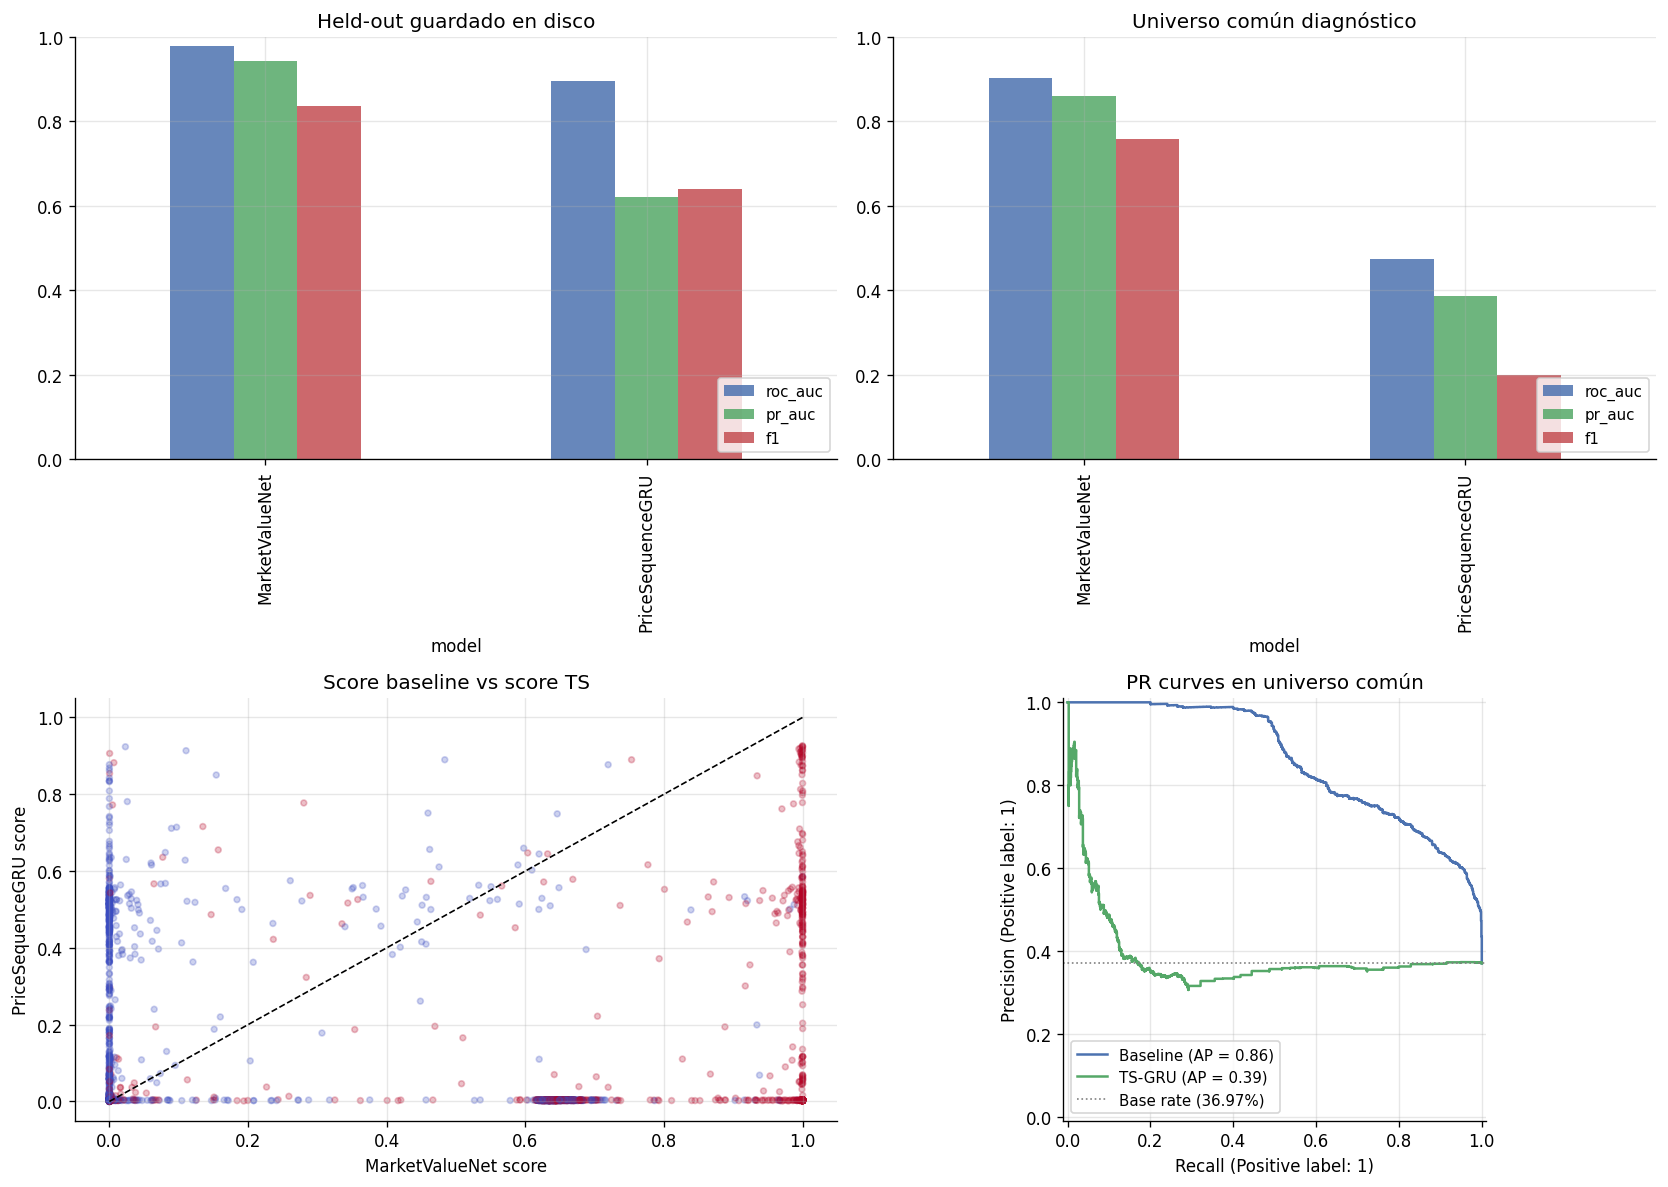

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
heldout_plot = heldout_df.set_index('model')[['roc_auc', 'pr_auc', 'f1']]
heldout_plot.plot.bar(ax=ax, color=[PALETTE[0], PALETTE[2], PALETTE[3]], alpha=0.85)
ax.set_title('Held-out guardado en disco')
ax.set_ylim(0, 1)
ax.legend(loc='lower right', fontsize=9)

ax = axes[0, 1]
common_plot = common_metrics_df.set_index('model')[['roc_auc', 'pr_auc', 'f1']]
common_plot.plot.bar(ax=ax, color=[PALETTE[0], PALETTE[2], PALETTE[3]], alpha=0.85)
ax.set_title('Universo común diagnóstico')
ax.set_ylim(0, 1)
ax.legend(loc='lower right', fontsize=9)

ax = axes[1, 0]
ax.scatter(df_cmp['model_score_baseline'], df_cmp['model_score_ts'], c=df_cmp['resolved'], cmap='coolwarm', alpha=0.25, s=12)
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_title('Score baseline vs score TS')
ax.set_xlabel('MarketValueNet score')
ax.set_ylabel('PriceSequenceGRU score')

ax = axes[1, 1]
PrecisionRecallDisplay.from_predictions(df_cmp['resolved'], df_cmp['model_score_baseline'], ax=ax, name='Baseline', color=PALETTE[0])
PrecisionRecallDisplay.from_predictions(df_cmp['resolved'], df_cmp['model_score_ts'], ax=ax, name='TS-GRU', color=PALETTE[2])
base_rate = float(df_cmp['resolved'].mean())
ax.axhline(base_rate, color='gray', linestyle=':', lw=1, label=f'Base rate ({base_rate:.2%})')
ax.set_title('PR curves en universo común')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'model_comparison_metrics.png', bbox_inches='tight')
plt.show()


## 7. Comparación en mercados activos

Después de la comparación offline, llevamos ambos modelos al mismo snapshot local de activos y aplicamos las mismas reglas de señales. Eso permite medir overlap real de ideas operativas.

In [7]:
class LocalClient:
    def __init__(self, markets):
        self.markets = markets
    def get_all_active_markets(self, max_markets=1000):
        return self.markets[:max_markets]
    def parse_market(self, market):
        return market

local_client = LocalClient(active_markets)
df_active_baseline = score_active_markets(
    baseline_model,
    local_client,
    baseline_pipeline,
    price_histories=price_histories,
    order_books=order_books,
    fetch_missing_context=False,
    top_k=len(active_markets),
    max_markets=len(active_markets),
)
df_active_ts = score_active_markets_ts(
    ts_model,
    local_client,
    price_histories=price_histories,
    fetch_missing_history=False,
    top_k=len(active_markets),
    max_markets=len(active_markets),
    seq_len=cfg['ts_data']['seq_len'],
    min_points=cfg['ts_data']['min_points'],
)

df_active_baseline = generate_signals(
    df_active_baseline,
    buy_threshold=cfg['scoring']['buy_threshold'],
    strong_buy_threshold=cfg['scoring']['strong_buy_threshold'],
    min_liquidity=cfg['scoring']['min_liquidity'],
    min_volume_24h=cfg['scoring']['min_volume_24h'],
    max_spread=cfg['scoring']['max_spread'],
)
df_active_ts = generate_signals(
    df_active_ts,
    buy_threshold=cfg['scoring']['buy_threshold'],
    strong_buy_threshold=cfg['scoring']['strong_buy_threshold'],
    min_liquidity=cfg['scoring']['min_liquidity'],
    min_volume_24h=cfg['scoring']['min_volume_24h'],
    max_spread=cfg['scoring']['max_spread'],
)

top_k = 20
top_base_ids = set(df_active_baseline.head(top_k)['id'])
top_ts_ids = set(df_active_ts.head(top_k)['id'])
overlap = len(top_base_ids & top_ts_ids)
print(f'Activos puntuados baseline: {len(df_active_baseline):,}')
print(f'Activos puntuados TS:       {len(df_active_ts):,}')
print(f'Overlap top-{top_k}:        {overlap} mercados')


TS scorer omitió mercados: {'insufficient_history': 14, 'exceptions': 0}


Activos puntuados baseline: 900
Activos puntuados TS:       886
Overlap top-20:        0 mercados


## 8. Overlap y desacuerdos más fuertes

La parte más útil de esta sección no es solo el overlap, sino los mercados donde ambos modelos discrepan mucho. Ahí suele estar la señal nueva del modelo secuencial.

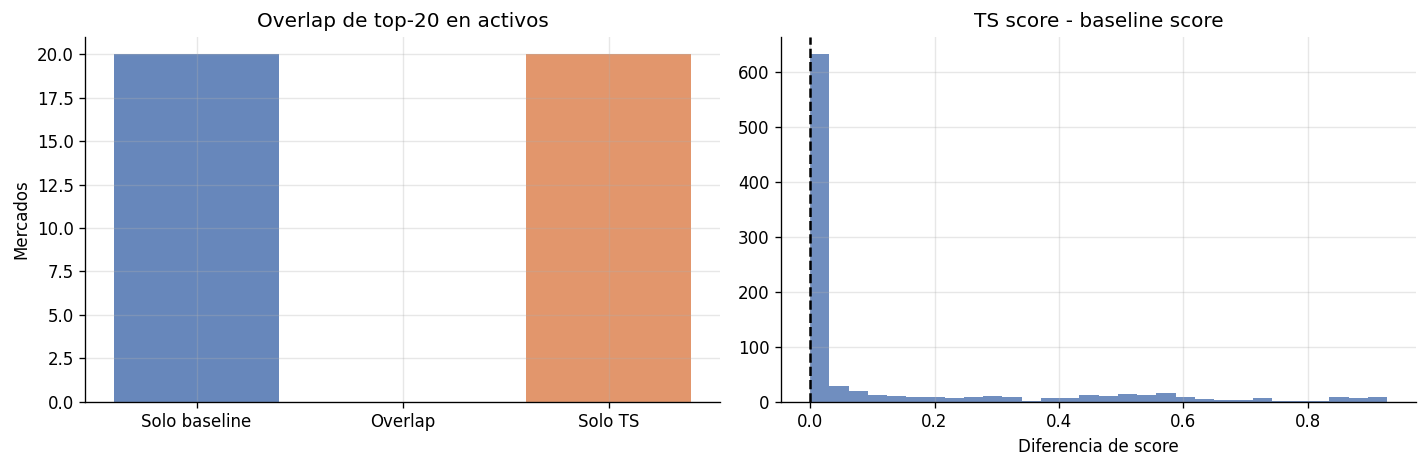

Desacuerdos más fuertes en activos:


,id,question,signal_baseline,signal_ts,model_score_baseline,model_score_ts,score_gap
70,1706294,"Will Iran strike UAE by April 30, 2026?",HOLD,STRONG BUY,0.0,0.927757,0.927757
826,1571571,Iran x Israel/US conflict ends by December 31?,HOLD,STRONG BUY,0.0,0.926898,0.926898
429,1397270,"Will Russia capture Lyman by December 31, 2026?",HOLD,STRONG BUY,0.0,0.921635,0.921635
835,566187,Will Arsenal win the 2025–26 English Premier L...,HOLD,STRONG BUY,0.0,0.919396,0.919396
291,1503698,Will Tisza win the most national list votes in...,HOLD,STRONG BUY,0.0,0.916393,0.916393
217,1611577,Will Trump visit China by June 30?,HOLD,STRONG BUY,0.0,0.914382,0.914382
418,1450859,Will the Virginia redistricting referendum pass?,HOLD,STRONG BUY,0.0,0.914156,0.914156
145,701501,"Will Bitcoin dip to $55,000 by December 31, 2026?",HOLD,STRONG BUY,0.0,0.900693,0.900693
824,658931,Will Michigan win the 2026 NCAA Tournament?,HOLD,STRONG BUY,0.0,0.898397,0.898397
37,1652672,Will Crude Oil (CL) hit (HIGH) $115 by end of ...,HOLD,STRONG BUY,0.0,0.895852,0.895852


In [8]:
overlap_df = pd.DataFrame({
    'bucket': ['Solo baseline', 'Overlap', 'Solo TS'],
    'count': [len(top_base_ids - top_ts_ids), len(top_base_ids & top_ts_ids), len(top_ts_ids - top_base_ids)],
})

active_compare = df_active_baseline[['id', 'question', 'model_score', 'signal']].merge(
    df_active_ts[['id', 'model_score', 'signal']],
    on='id',
    suffixes=('_baseline', '_ts'),
)
active_compare['score_gap'] = active_compare['model_score_ts'] - active_compare['model_score_baseline']
disagreements = active_compare.sort_values('score_gap', key=np.abs, ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(overlap_df['bucket'], overlap_df['count'], color=[PALETTE[0], PALETTE[2], PALETTE[1]], alpha=0.85)
ax.set_title('Overlap de top-20 en activos')
ax.set_ylabel('Mercados')

ax = axes[1]
ax.hist(active_compare['score_gap'], bins=30, color=PALETTE[0], alpha=0.8)
ax.axvline(0, color='black', linestyle='--', lw=1.5)
ax.set_title('TS score - baseline score')
ax.set_xlabel('Diferencia de score')

plt.tight_layout()
plt.savefig(FIGURES / 'model_comparison_overlap.png', bbox_inches='tight')
plt.show()

print('Desacuerdos más fuertes en activos:')
display(disagreements[['id', 'question', 'signal_baseline', 'signal_ts', 'model_score_baseline', 'model_score_ts', 'score_gap']])


## 9. Cómo interpretar el resultado final

Al cerrar este notebook, una lectura útil es:
- si el GRU mejora métricas offline o no
- si propone mercados distintos al baseline en activos
- si las discrepancias parecen razonables según la trayectoria del precio

Si ambos modelos aportan algo distinto, ya tienes base para explorar ensemble o reglas de consenso más adelante.